# 變電所恢復時間資料分析

1. **資料讀取**
   - 載入 `data/transformer_clean.csv`
   - 確認欄位與資料筆數

2. **探索性分析（EDA）**

   2.1 基本統計
   - 計算 `Duration (minutes)` 的 mean、median、std、min、max
   - 可觀察中位數遠小於平均值之重尾現象

   2.2 各災害種類的 Duration 統計
   - 以 `Cause` 為分組依據，計算各類別統計量

   2.3 Cause 分布統計
   - 計算各 Cause 類別的筆數與佔比，繪製圓餅圖

   2.4 Duration 直方圖
   - 線性尺度（觀察主體分布）與 log 尺度（觀察尾部行為）

3. **CCDF 計算與繪製**
   - 計算經驗 CCDF：P(X > x)，以 log-log 尺度呈現
   - 作為後續分布擬合比較的基準圖

4. **多分布擬合（MLE + AIC）**
   - 候選分布：Log-normal、Weibull、Gamma、Burr (XII)、Gen. Pareto、Gen. Gamma
   - 以 MLE 估計參數，以 AIC 與 KS D 統計量作為模型選擇依據
   - 視覺化 CCDF 比較圖，確認各分布在全域與尾部的貼合情形

5. **說明與討論：KS test 不適用於本題**
   - 說明部分文獻使用 Binary search + KS test 搜尋 log-normal 有效範圍的原理
   - 分析為何 KS test 在重尾資料場景下不適用於本題目

6. **相對誤差檢核**
   - 逐點計算實際 CCDF 與 Log-normal 理論 CCDF 的相對誤差
   - 輸出一般統計與離散化統計表

7. **結論：直接使用全域擬合**
   - 異常值已於前處理階段以 DOE-417 WECC global_max 統一截斷，無需再設擬合截斷點
   - 說明二次人為截斷之反效果，確立全域 Log-normal 擬合作為恢復時間模擬基礎

8. **保守設計驗證**
   - 計算逐點估計誤差期望值 ΔE[T]
   - 驗證 Log-normal 全域擬合在整體期望值層面偏向保守側

9. **補充說明**
   - 討論尾部是否額外進行線性回歸擬合之取捨判斷

# 1. 讀取資料

In [1]:
import pandas as pd
import os

DATA_DIR = "data"

# 載入清理後的資料
df = pd.read_csv(os.path.join(DATA_DIR, "transformer_clean.csv"))

# 確認欄位與資料筆數
print(f"資料筆數：{len(df)}")
print(f"欄位：{df.columns.tolist()}")
df.head()

資料筆數：275
欄位：['Name', 'Out Datetime', 'In Datetime', 'Voltage High (kV)', 'Voltage Low (kV)', 'Duration (minutes)', 'Outage Type', 'Cause', 'year', 'outage_year', 'threshold']


,Name,Out Datetime,In Datetime,Voltage High (kV),Voltage Low (kV),Duration (minutes),Outage Type,Cause,year,outage_year,threshold
0,Grand Coulee: 500/230kV CSY Tie Bank,2013-02-06 10:27:00,2013-02-06 11:21:00,500.0,230.0,54,Auto,Foreign Trouble,2013,{2013},49487.0
1,Olympia: 287/230kV Transformer 3,2013-02-06 10:27:00,2013-02-06 10:54:00,287.0,230.0,27,Auto,Foreign Trouble,2013,{2013},49487.0
2,Tacoma: 500/230kV Transformer 5,2013-03-25 17:15:00,2013-03-25 17:21:00,500.0,230.0,6,Auto,Other,2013,{2013},49487.0
3,Big Eddy: 500/230kV Transformer 2,2013-04-10 06:20:00,2013-04-11 21:14:00,500.0,230.0,2334,Auto,Unknown,2013,{2013},49487.0
4,Olympia: 287/230kV Transformer 3,2013-05-26 12:54:00,2013-05-26 21:52:00,287.0,230.0,538,Auto,Unknown,2013,{2013},49487.0


# 2. 探索性分析（EDA）

## 2.1 基本統計資料

* 紀錄停電時間的 "平均值", "中位數", "標準差", "最小值", "最大值" 等資訊

* 可以看到中位數遠小於平均值的重尾現象，也就是具有極端事件影響導致平均復電時間較長

In [ ]:
# 統計資料
stats = df["Duration (minutes)"].agg(["mean", "median", "std", "min", "max"])
stats.index = ["Mean", "Median", "Std", "Min", "Max"]
stats.to_frame("Duration (minutes)").round(2)

,Duration (minutes)
Mean,743.53
Median,107.00
Std,2108.75
Min,1.00
Max,15868.00


## 2.2 損害原因與復電時間統計資料

In [3]:
# 各災害種類的 Duration 統計
cause_stats = df.groupby("Cause")["Duration (minutes)"].agg(["count", "mean", "median", "std", "min", "max"])
cause_stats.columns = ["Count", "Mean", "Median", "Std", "Min", "Max"]
cause_stats.round(2)

,Count,Mean,Median,Std,Min,Max
Cause,,,,,,
Equipment Failure,68,1124.87,222.5,2779.95,2,15868
Foreign Trouble,6,535.00,67.5,1164.90,2,2911
Lightning,26,125.04,4.0,309.03,1,1347
Other,101,614.13,63.0,1953.39,1,12673
Unknown,50,915.90,105.5,2373.39,2,11520
Weather,17,530.65,219.0,707.19,2,1731
Wind,7,667.86,624.0,548.13,1,1392


## 2.3 損害原因比例

* 類別說明

    | 標準類別 | 對應原始值 |
    |---|---|
    | `Unknown` | `Unknown`, `Not Reported` |
    | `Lightning` | `Lightning` |
    | `Wind` | `Wind`, `Tree blown` |
    | `Weather` | `Weather`, `Contamination`, `Smoke`, `Fire` |
    | `Foreign Trouble` | `Foreign Trouble`, `Bird droppings`, `Bird or Animal`, `Kite`, `Tree cut`, `Tree` |
    | `Equipment Failure` | `Terminal Equipment Failure`, `Equipment/Miscellaneous`, `Line Material Failure`, `Imp Install/Design/Applica`, `Improper Relaying` |
    | `Other` | 其餘所有（`Forced (Configuration)`, `Power System Condition`, `Human Element`, `Sympathetic`, `Another Line`, `Substation Operations`, `Dispatcher`, `TT Noise`, `Maintenance`, `Construction` 等） |

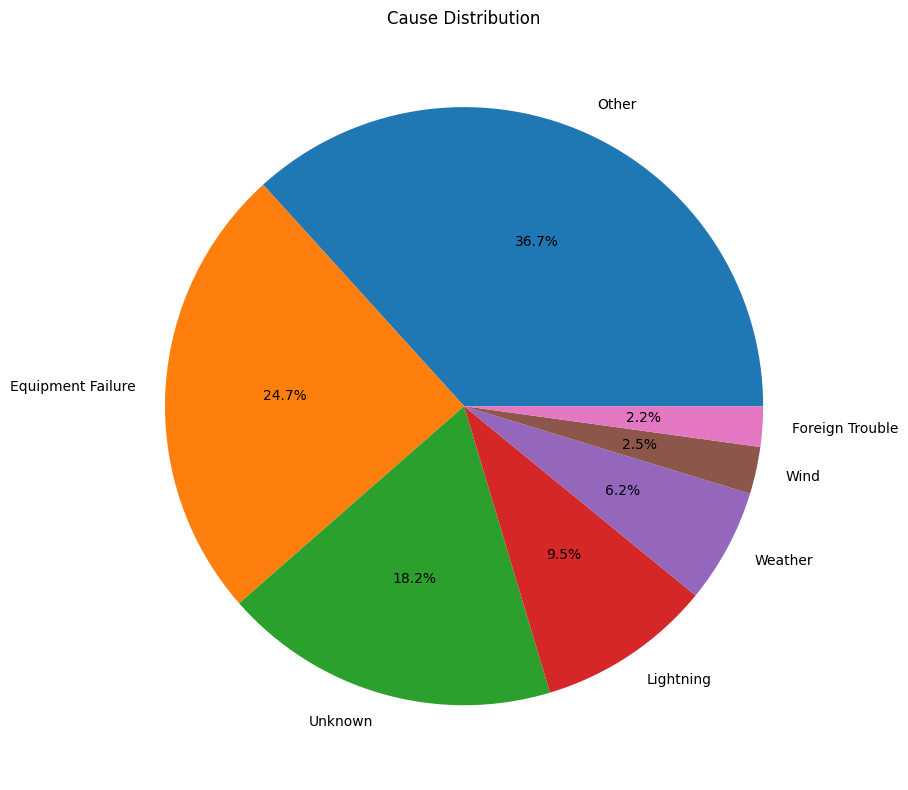

In [ ]:
# Cause 分布統計
import matplotlib.pyplot as plt

cause_counts = df["Cause"].value_counts()

plt.figure(figsize=(10,8))
plt.pie(cause_counts, labels=cause_counts.index, autopct="%1.1f%%", startangle=0)
plt.title("Cause Distribution")
plt.tight_layout()
plt.show()

## 2.4 Duration 直方圖

1. 線性直方圖

2. Log 尺度下直方圖

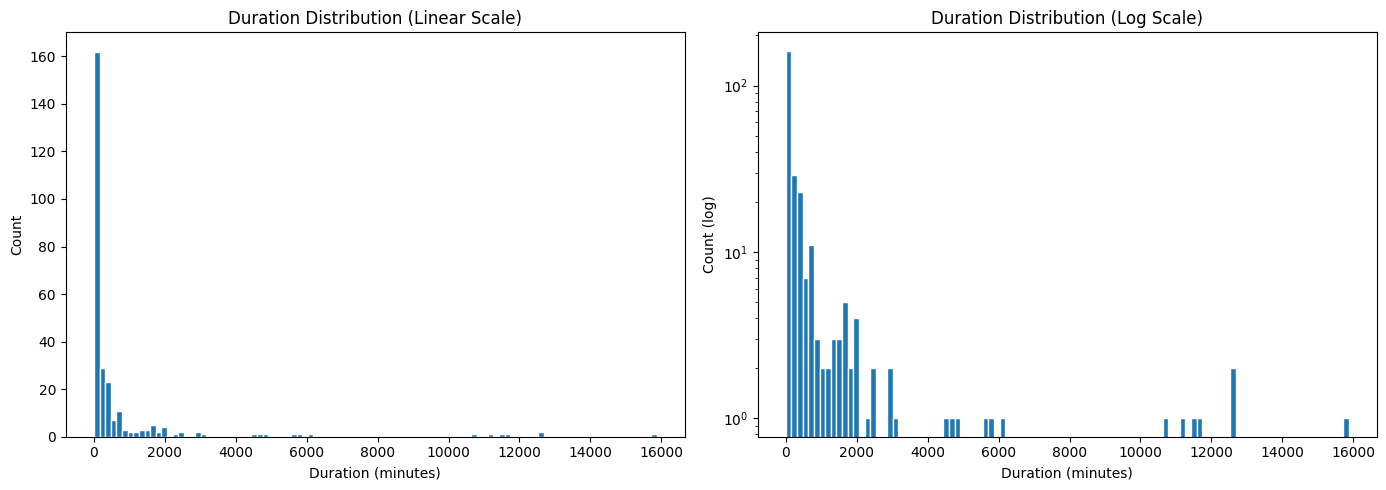

In [ ]:
# Duration 直方圖
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 線性尺度
axes[0].hist(df["Duration (minutes)"], bins=100, edgecolor="white")
axes[0].set_title("Duration Distribution (Linear Scale)")
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Count")

# Log 尺度
axes[1].hist(df["Duration (minutes)"], bins=100, edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("Duration Distribution (Log Scale)")
axes[1].set_xlabel("Duration (minutes)")
axes[1].set_ylabel("Count (log)")

plt.tight_layout()
plt.show()

# 3. CCDF 計算與繪製

* 目的 : 計算並繪製修復時間的經驗互補累積分布函數（CCDF），以 log-log 尺度呈現。若分布具有重尾特性，資料點在 log-log 圖上會呈現近似線性的行為。此圖將作為後續 log-normal 擬合比較的基準。

* 橫軸 : 修復時間（分鐘），以 log 尺度呈現，範圍從 1 分鐘到數萬分鐘，跨越多個數量級。

* 縱軸 : P(X > x) 互補累積機率，即修復時間超過 x 分鐘的機率，以 log 尺度呈現。數值越小代表該修復時間越罕見。

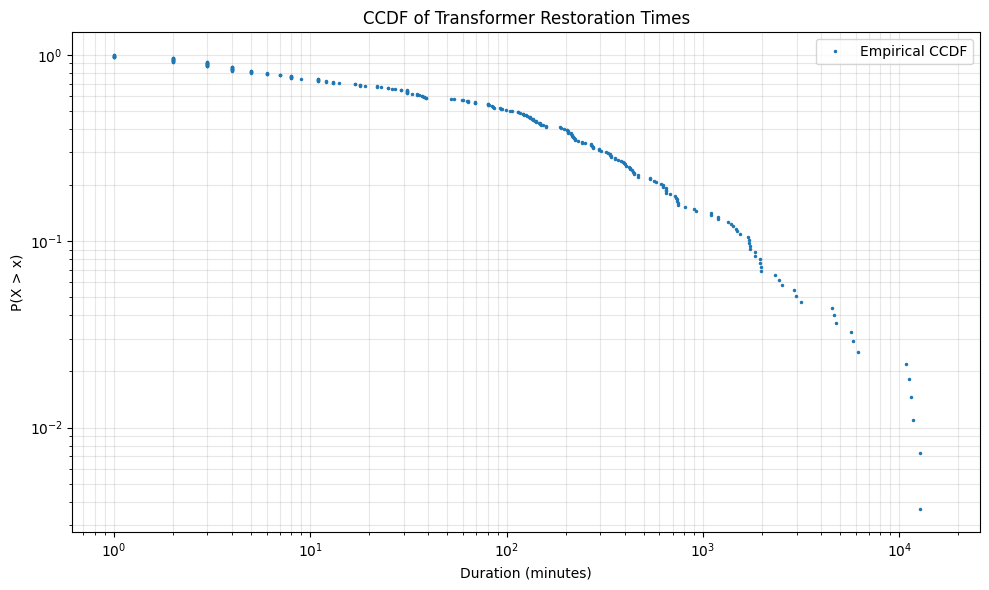

In [ ]:
import numpy as np

# 依據修復時間做排序
duration_sorted = np.sort(df["Duration (minutes)"].values)

# 發生該修復時間的互補累積機率 (1-累積機率)
# 使用 arange 將 numpy 陣列做 [1,2...] 排列，也就是記數
ccdf = 1 - np.arange(1, len(duration_sorted) + 1) / len(duration_sorted)

plt.figure(figsize=(10, 6))
plt.loglog(duration_sorted, ccdf, marker=".", linestyle="none", markersize=3, label="Empirical CCDF")
plt.xlabel("Duration (minutes)")
plt.ylabel("P(X > x)")
plt.title("CCDF of Transformer Restoration Times")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()